# 03 - Patrones temporales

## 1. Dependencias

In [1]:
#Instalar dependencias
%pip install pandas numpy matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


## 2. Configuración

In [2]:
#Librerías
import platform
import sys
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import FuncFormatter

In [3]:
#Configuración
SEMILLA = 20260727
UMBRAL_REGULARIDAD = 0.75
MIN_FECHAS_REGULARIDAD = 3
MIN_SEMANAS_TENDENCIA = 8
MIN_TRANSACCIONES_TENDENCIA = 5
UMBRAL_CAMBIO_PCT = 25.0
MIN_ANTECEDENTES_EVENTO = 5
UMBRAL_EVENTO_INUSUAL = 3.5

ruta_transacciones = Path('../Datasets/transacciones_contextualizadas.csv')
ruta_perfiles = Path('../Datasets/perfil_integral_usuario.csv')
ruta_modelo_transacciones = Path('../Modelos/02_clasificacion_transacciones.joblib')
ruta_resultados = Path('../Resultados')
ruta_graficas = ruta_resultados / 'Graficas'

versiones = pd.DataFrame([
    {'componente': 'python', 'version': sys.version.split()[0]},
    {'componente': 'pandas', 'version': pd.__version__},
    {'componente': 'numpy', 'version': np.__version__},
    {'componente': 'matplotlib', 'version': plt.matplotlib.__version__},
    {'componente': 'sistema', 'version': platform.platform()},
])

display(versiones)

,componente,version
0,python,3.14.3
1,pandas,3.0.3
2,numpy,2.5.1
3,matplotlib,3.11.1
4,sistema,macOS-26.5.2-arm64-arm-64bit-Mach-O


## 3. Carga y contrato temporal

In [4]:
#Cargar datos
assert ruta_transacciones.exists(), f'No existe {ruta_transacciones}'
assert ruta_perfiles.exists(), f'No existe {ruta_perfiles}'
assert ruta_modelo_transacciones.exists(), 'Ejecuta primero el notebook 02'

transacciones = pd.read_csv(ruta_transacciones, low_memory=False)
perfiles = pd.read_csv(ruta_perfiles, low_memory=False)
artefacto_transacciones = joblib.load(ruta_modelo_transacciones)
transacciones['fecha'] = pd.to_datetime(transacciones['fecha'], errors='coerce')
transacciones['valor'] = pd.to_numeric(transacciones['valor'], errors='coerce')
transacciones = transacciones.sort_values(['perfil_id', 'fecha', 'transaccion_id']).reset_index(drop=True)
display(transacciones.head(5))
print('Modelo cargado: {}'.format(artefacto_transacciones['version_modelo']))

,transaccion_id,perfil_id,version_perfil_aplicada,fecha,descripcion_original,descripcion_normalizada,valor,moneda,direccion,tipo_movimiento,...,es_sintetico,version_taxonomia,version_esquema,huella_registro,estado_ingreso_perfil,regularidad_movimiento,modalidad_ingreso_observada,categoria_confirmada_usuario,confirmacion_usuario,fuente_etiqueta
0,TX_0001_0001,PERF_0001,perfil_estructurado_v2.0,2026-04-02,PAGO ARRIENDO,pago arriendo,427000,COP,salida,gasto,...,si,transacciones_mvp_v2.0,fincoach_mvp_estructurado_v2.0,c3f464ff5d962078a09fe669e9106f4b605514a4da16f0...,mixto,fijo,NaN,Vivienda,si,historia_controlada_y_confirmacion_usuario
1,TX_0001_0002,PERF_0001,perfil_estructurado_v2.0,2026-04-02,ALMUERZO,almuerzo,54000,COP,salida,gasto,...,si,transacciones_mvp_v2.0,fincoach_mvp_estructurado_v2.0,9b191e9afda1262a80886c82132d2c94126eb857601b75...,mixto,fijo,NaN,Alimentación,si,historia_controlada_y_confirmacion_usuario
2,TX_0001_0003,PERF_0001,perfil_estructurado_v2.0,2026-04-03,REPUESTO TRANSPORTE,repuesto transporte,70000,COP,salida,gasto,...,si,transacciones_mvp_v2.0,fincoach_mvp_estructurado_v2.0,e2bb362afb44def6cf833ee79af0d2c428d31725dfa56f...,mixto,variable,NaN,Transporte,si,historia_controlada_y_confirmacion_usuario
3,TX_0001_0004,PERF_0001,perfil_estructurado_v2.0,2026-04-03,HOTEL TURISMO,hotel turismo,90000,COP,salida,gasto,...,si,transacciones_mvp_v2.0,fincoach_mvp_estructurado_v2.0,f7f96ef9f08995f8dbc49114020380072ad51e569736ac...,mixto,fijo,NaN,Ocio,si,historia_controlada_y_confirmacion_usuario
4,TX_0001_0005,PERF_0001,perfil_estructurado_v2.0,2026-04-05,APP DOMICILIO COMIDA,app domicilio comida,53000,COP,salida,gasto,...,si,transacciones_mvp_v2.0,fincoach_mvp_estructurado_v2.0,2b7f90d12334ad1d6db513811d64b188119924d876209b...,mixto,variable,NaN,Alimentación,si,historia_controlada_y_confirmacion_usuario


Modelo cargado: fincoach_transacciones_mvp_v2


In [5]:
#Validar contrato
columnas_requeridas = [
    'transaccion_id',
    'perfil_id',
    'fecha',
    'descripcion_normalizada',
    'valor',
    'direccion',
    'tipo_movimiento',
    'categoria_principal',
    'es_recurrente',
    'regularidad_movimiento',
    'estado_ingreso_perfil',
    'estado_clasificacion',
    'particion',
]

columnas_faltantes = sorted(set(columnas_requeridas) - set(transacciones.columns))
errores_contrato = pd.DataFrame([
    {'control': 'columnas requeridas', 'errores': len(columnas_faltantes)},
    {'control': 'fechas válidas', 'errores': int(transacciones['fecha'].isna().sum())},
    {'control': 'valores numéricos', 'errores': int(transacciones['valor'].isna().sum())},
    {'control': 'valores positivos', 'errores': int(transacciones['valor'].le(0).sum())},
    {'control': 'perfil disponible', 'errores': int(transacciones['perfil_id'].isna().sum())},
    {'control': 'descripción disponible', 'errores': int(transacciones['descripcion_normalizada'].isna().sum())},
])

errores_contexto = pd.DataFrame([
    {'control': 'perfiles asociados', 'errores': int((~transacciones['perfil_id'].isin(perfiles['perfil_id'])).sum())},
    {'control': 'modelo 02 actualizado', 'errores': int(artefacto_transacciones['version_modelo'] != 'fincoach_transacciones_mvp_v2')},
    {'control': 'regularidad válida', 'errores': int((~transacciones['regularidad_movimiento'].isin(['fijo', 'variable', 'estacional'])).sum())},
])

display(errores_contrato)
display(errores_contexto)
assert not columnas_faltantes, f'Faltan columnas: {columnas_faltantes}'
assert errores_contrato['errores'].eq(0).all(), 'El contrato temporal contiene errores'
assert errores_contexto['errores'].eq(0).all(), 'El contexto temporal contiene errores'

,control,errores
0,columnas requeridas,0
1,fechas válidas,0
2,valores numéricos,0
3,valores positivos,0
4,perfil disponible,0
5,descripción disponible,0


,control,errores
0,perfiles asociados,0
1,modelo 02 actualizado,0
2,regularidad válida,0


## 4. Cobertura de la historia

In [6]:
#Medir cobertura
cobertura_perfiles = transacciones.groupby('perfil_id').agg(
    fecha_inicial=('fecha', 'min'),
    fecha_final=('fecha', 'max'),
    transacciones=('transaccion_id', 'size'),
    dias_con_movimientos=('fecha', 'nunique'),
    categorias=('categoria_principal', 'nunique'),
).reset_index()

cobertura_perfiles['dias_observados'] = (
    cobertura_perfiles['fecha_final'] - cobertura_perfiles['fecha_inicial']
).dt.days.add(1)

resumen_cobertura = cobertura_perfiles[
    ['transacciones', 'dias_con_movimientos', 'dias_observados', 'categorias']
].describe().round(2)

display(resumen_cobertura)
display(cobertura_perfiles.head(5))


,transacciones,dias_con_movimientos,dias_observados,categorias
count,200.00,200.00,200.00,200.00
mean,86.42,54.72,89.45,13.98
std,11.65,5.82,1.69,1.31
min,55.00,40.00,84.00,10.00
25%,78.75,52.00,89.00,13.00
50%,90.00,56.00,90.00,14.00
75%,95.00,59.00,91.00,15.00
max,100.00,68.00,91.00,17.00


,perfil_id,fecha_inicial,fecha_final,transacciones,dias_con_movimientos,categorias,dias_observados
0,PERF_0001,2026-04-02,2026-06-30,96,51,14,90
1,PERF_0002,2026-04-02,2026-06-29,89,58,12,89
2,PERF_0003,2026-04-02,2026-06-28,99,60,14,88
3,PERF_0004,2026-04-01,2026-06-30,98,61,15,91
4,PERF_0005,2026-04-01,2026-06-30,65,48,14,91


## 5. Recurrencias y regularidades

In [7]:
#Definir cadencias
cadencias = pd.DataFrame([
    {'cadencia': 'diaria', 'dias_objetivo': 1, 'tolerancia_dias': 1},
    {'cadencia': 'semanal', 'dias_objetivo': 7, 'tolerancia_dias': 2},
    {'cadencia': 'quincenal', 'dias_objetivo': 15, 'tolerancia_dias': 3},
    {'cadencia': 'mensual', 'dias_objetivo': 30, 'tolerancia_dias': 6},
    {'cadencia': 'bimestral', 'dias_objetivo': 60, 'tolerancia_dias': 12},
])

display(cadencias)

,cadencia,dias_objetivo,tolerancia_dias
0,diaria,1,1
1,semanal,7,2
2,quincenal,15,3
3,mensual,30,6
4,bimestral,60,12


In [8]:
#Evaluar fechas
def evaluar_fechas(fechas):
    fechas_unicas = pd.Series(pd.to_datetime(fechas).dropna().unique()).sort_values().reset_index(drop=True)
    cantidad_fechas = len(fechas_unicas)

    if cantidad_fechas < 2:
        return {
            'fechas_distintas': cantidad_fechas,
            'intervalo_mediano_dias': np.nan,
            'dispersion_intervalo_dias': np.nan,
            'cadencia_observada': 'no_determinable',
            'regularidad_pct': 0.0,
            'estado_patron': 'evidencia_insuficiente',
            'naturaleza_observada': 'no_determinable',
            'nivel_incertidumbre': 'alta',
        }

    intervalos = fechas_unicas.diff().dt.days.dropna().to_numpy()
    evaluaciones = cadencias.copy()
    evaluaciones['regularidad'] = evaluaciones.apply(
        lambda fila: np.mean(
            np.abs(intervalos - fila['dias_objetivo']) <= fila['tolerancia_dias']
        ),
        axis=1,
    )
    evaluaciones['distancia_mediana'] = np.abs(
        np.median(intervalos) - evaluaciones['dias_objetivo']
    )
    mejor = evaluaciones.sort_values(
        ['regularidad', 'distancia_mediana'],
        ascending=[False, True],
    ).iloc[0]

    regularidad = float(mejor['regularidad'])
    cadencia = mejor['cadencia'] if regularidad >= UMBRAL_REGULARIDAD else 'irregular'

    if cantidad_fechas < MIN_FECHAS_REGULARIDAD and regularidad >= UMBRAL_REGULARIDAD:
        estado = 'posible_recurrencia'
        incertidumbre = 'alta'
    elif cantidad_fechas >= MIN_FECHAS_REGULARIDAD and regularidad >= UMBRAL_REGULARIDAD:
        estado = 'regularidad_observada'
        incertidumbre = 'media' if cantidad_fechas == MIN_FECHAS_REGULARIDAD else 'baja'
    else:
        estado = 'sin_regularidad_suficiente'
        incertidumbre = 'media'

    if cadencia == 'bimestral' and regularidad >= UMBRAL_REGULARIDAD:
        naturaleza = 'estacional'
    elif estado in ['posible_recurrencia', 'regularidad_observada']:
        naturaleza = 'fijo'
    else:
        naturaleza = 'variable'

    return {
        'fechas_distintas': cantidad_fechas,
        'intervalo_mediano_dias': round(float(np.median(intervalos)), 2),
        'dispersion_intervalo_dias': round(float(np.median(np.abs(intervalos - np.median(intervalos)))), 2),
        'cadencia_observada': cadencia,
        'regularidad_pct': round(regularidad * 100, 2),
        'estado_patron': estado,
        'naturaleza_observada': naturaleza,
        'nivel_incertidumbre': incertidumbre,
    }

In [9]:
#Detectar recurrencias
def detectar_recurrencias(datos):
    claves = [
        'perfil_id',
        'descripcion_normalizada',
        'direccion',
        'tipo_movimiento',
        'categoria_principal',
    ]
    resultados = []

    for clave, grupo in datos.groupby(claves, dropna=False, sort=False):
        evaluacion = evaluar_fechas(grupo['fecha'])
        resultados.append({
            'perfil_id': clave[0],
            'descripcion_normalizada': clave[1],
            'direccion': clave[2],
            'tipo_movimiento': clave[3],
            'categoria_principal': clave[4],
            'ocurrencias': len(grupo),
            'fecha_inicial': grupo['fecha'].min(),
            'fecha_final': grupo['fecha'].max(),
            'valor_mediano': round(float(grupo['valor'].median()), 2),
            'dataset_declara_recurrente': bool(grupo['es_recurrente'].eq('si').any()),
            'regularidad_dataset': grupo['regularidad_movimiento'].mode().iat[0],
            'estado_ingreso_perfil': grupo['estado_ingreso_perfil'].mode().iat[0],
            **evaluacion,
        })

    return pd.DataFrame(resultados)

recurrencias = detectar_recurrencias(transacciones)
display(recurrencias.head(10))

,perfil_id,descripcion_normalizada,direccion,tipo_movimiento,categoria_principal,ocurrencias,fecha_inicial,fecha_final,valor_mediano,dataset_declara_recurrente,regularidad_dataset,estado_ingreso_perfil,fechas_distintas,intervalo_mediano_dias,dispersion_intervalo_dias,cadencia_observada,regularidad_pct,estado_patron,naturaleza_observada,nivel_incertidumbre
0,PERF_0001,pago arriendo,salida,gasto,Vivienda,3,2026-04-02,2026-06-02,583000.0,True,fijo,mixto,3,30.5,2.5,mensual,100.0,regularidad_observada,fijo,media
1,PERF_0001,almuerzo,salida,gasto,Alimentación,2,2026-04-02,2026-06-03,67000.0,True,fijo,mixto,2,62.0,0.0,bimestral,100.0,posible_recurrencia,estacional,alta
2,PERF_0001,repuesto transporte,salida,gasto,Transporte,1,2026-04-03,2026-04-03,70000.0,False,variable,mixto,1,NaN,NaN,no_determinable,0.0,evidencia_insuficiente,no_determinable,alta
3,PERF_0001,hotel turismo,salida,gasto,Ocio,2,2026-04-03,2026-06-19,89500.0,True,fijo,mixto,2,77.0,0.0,irregular,0.0,sin_regularidad_suficiente,variable,media
4,PERF_0001,app domicilio comida,salida,gasto,Alimentación,1,2026-04-05,2026-04-05,53000.0,False,variable,mixto,1,NaN,NaN,no_determinable,0.0,evidencia_insuficiente,no_determinable,alta
5,PERF_0001,accesorios personales,salida,gasto,Vestimenta,1,2026-04-05,2026-04-05,76000.0,False,variable,mixto,1,NaN,NaN,no_determinable,0.0,evidencia_insuficiente,no_determinable,alta
6,PERF_0001,pago ingreso principal,entrada,ingreso_generado,Ingresos laborales,3,2026-04-05,2026-06-05,1350000.0,True,fijo,mixto,3,30.5,0.5,mensual,100.0,regularidad_observada,fijo,media
7,PERF_0001,arreglo vivienda,salida,gasto,Vivienda,2,2026-04-07,2026-04-12,87000.0,False,variable,mixto,2,5.0,0.0,semanal,100.0,posible_recurrencia,fijo,alta
8,PERF_0001,drogueria,salida,gasto,Salud,1,2026-04-07,2026-04-07,130000.0,False,variable,mixto,1,NaN,NaN,no_determinable,0.0,evidencia_insuficiente,no_determinable,alta
9,PERF_0001,recarga transporte,salida,gasto,Transporte,4,2026-04-09,2026-06-21,141500.0,True,fijo,mixto,3,36.5,1.5,irregular,50.0,sin_regularidad_suficiente,variable,media


In [10]:
#Resumir recurrencias
resumen_recurrencias = recurrencias.groupby(
    ['estado_patron', 'nivel_incertidumbre'],
    dropna=False,
).size().rename('grupos').reset_index()

contraste_recurrencia = pd.crosstab(
    recurrencias['dataset_declara_recurrente'].map({True: 'si', False: 'no'}),
    recurrencias['estado_patron'],
)

contraste_regularidad = pd.crosstab(
    recurrencias['regularidad_dataset'],
    recurrencias['naturaleza_observada'],
)
comparables_regularidad = recurrencias['estado_patron'].eq('regularidad_observada')
coincidencia_regularidad_pct = round(
    recurrencias.loc[comparables_regularidad, 'regularidad_dataset'].eq(
        recurrencias.loc[comparables_regularidad, 'naturaleza_observada']
    ).mean() * 100,
    2,
)

display(resumen_recurrencias)
display(contraste_recurrencia)
display(contraste_regularidad)
print(f'Coincidencia en regularidades confirmadas: {coincidencia_regularidad_pct:.2f}%')

,estado_patron,nivel_incertidumbre,grupos
0,evidencia_insuficiente,alta,4962
1,posible_recurrencia,alta,1182
2,regularidad_observada,baja,6
3,regularidad_observada,media,496
4,sin_regularidad_suficiente,media,2256


estado_patron,evidencia_insuficiente,posible_recurrencia,regularidad_observada,sin_regularidad_suficiente
dataset_declara_recurrente,,,,
no,4951,369,3,238
si,11,813,499,2018


naturaleza_observada,estacional,fijo,no_determinable,variable
regularidad_dataset,,,,
estacional,3,0,3,26
fijo,341,971,11,2018
variable,0,369,4948,212


Coincidencia en regularidades confirmadas: 99.40%


## 6. Tendencias semanales

In [11]:
#Detectar tendencias
def detectar_tendencias(datos):
    base = datos.copy()
    base['semana'] = base['fecha'] - pd.to_timedelta(base['fecha'].dt.weekday, unit='D')
    resultados = []

    for clave, grupo in base.groupby(['perfil_id', 'direccion'], sort=False):
        serie = grupo.groupby('semana')['valor'].sum().sort_index()
        indice = pd.date_range(serie.index.min(), serie.index.max(), freq='7D')
        serie = serie.reindex(indice, fill_value=0.0)
        semanas = len(serie)
        cantidad = len(grupo)

        if semanas < MIN_SEMANAS_TENDENCIA or cantidad < MIN_TRANSACCIONES_TENDENCIA:
            pendiente = np.nan
            cambio_pct = np.nan
            estado = 'evidencia_insuficiente'
            incertidumbre = 'alta'
        else:
            eje = np.arange(semanas, dtype=float)
            pendiente = float(np.polyfit(eje, serie.to_numpy(dtype=float), 1)[0])
            promedio = float(serie.mean())
            cambio_pct = pendiente * max(semanas - 1, 1) / max(promedio, 1.0) * 100

            if cambio_pct >= UMBRAL_CAMBIO_PCT:
                estado = 'aumento_observado'
            elif cambio_pct <= -UMBRAL_CAMBIO_PCT:
                estado = 'disminucion_observada'
            else:
                estado = 'estabilidad_observada'

            incertidumbre = 'media'

        resultados.append({
            'perfil_id': clave[0],
            'direccion': clave[1],
            'semanas_observadas': semanas,
            'transacciones_observadas': cantidad,
            'promedio_semanal': round(float(serie.mean()), 2),
            'pendiente_semanal': round(pendiente, 2) if pd.notna(pendiente) else np.nan,
            'cambio_relativo_pct': round(cambio_pct, 2) if pd.notna(cambio_pct) else np.nan,
            'estado_tendencia': estado,
            'nivel_incertidumbre': incertidumbre,
        })

    return pd.DataFrame(resultados)

tendencias = detectar_tendencias(transacciones)
display(tendencias.groupby(['direccion', 'estado_tendencia']).size().rename('perfiles').reset_index())
display(tendencias.head(10))

,direccion,estado_tendencia,perfiles
0,entrada,aumento_observado,61
1,entrada,disminucion_observada,41
2,entrada,estabilidad_observada,42
3,entrada,evidencia_insuficiente,52
4,salida,aumento_observado,44
5,salida,disminucion_observada,71
6,salida,estabilidad_observada,85


,perfil_id,direccion,semanas_observadas,transacciones_observadas,promedio_semanal,pendiente_semanal,cambio_relativo_pct,estado_tendencia,nivel_incertidumbre
0,PERF_0001,salida,13,86,815538.46,1269.23,1.87,estabilidad_observada,media
1,PERF_0001,entrada,14,10,959285.71,112421.98,152.35,aumento_observado,media
2,PERF_0002,salida,14,86,767785.71,-25114.29,-42.52,disminucion_observada,media
3,PERF_0002,entrada,10,3,318000.00,NaN,NaN,evidencia_insuficiente,alta
4,PERF_0003,salida,13,58,1101307.69,-38203.30,-41.63,disminucion_observada,media
5,PERF_0003,entrada,13,41,2019000.00,123186.81,73.22,aumento_observado,media
6,PERF_0004,salida,14,76,2620000.00,72756.04,36.10,aumento_observado,media
7,PERF_0004,entrada,13,22,1822000.00,-4060.44,-2.67,estabilidad_observada,media
8,PERF_0005,salida,13,61,843230.77,25774.73,36.68,aumento_observado,media
9,PERF_0005,entrada,14,4,115714.29,NaN,NaN,evidencia_insuficiente,alta


## 7. Eventos inusuales dentro del historial propio

In [12]:
#Detectar eventos inusuales
def detectar_eventos_inusuales(datos):
    claves = ['perfil_id', 'categoria_principal', 'direccion']
    resultados = []

    for clave, grupo in datos.sort_values('fecha').groupby(claves, sort=False):
        historial = []

        for fila in grupo.itertuples(index=False):
            if len(historial) >= MIN_ANTECEDENTES_EVENTO:
                antecedentes = np.asarray(historial, dtype=float)
                mediana = float(np.median(antecedentes))
                mad = float(np.median(np.abs(antecedentes - mediana)))
                escala = 1.4826 * mad

                if escala == 0:
                    q25, q75 = np.percentile(antecedentes, [25, 75])
                    escala = float((q75 - q25) / 1.349)

                puntaje = abs(float(fila.valor) - mediana) / escala if escala > 0 else np.nan

                if pd.notna(puntaje) and puntaje >= UMBRAL_EVENTO_INUSUAL:
                    resultados.append({
                        'transaccion_id': fila.transaccion_id,
                        'perfil_id': clave[0],
                        'categoria_principal': clave[1],
                        'direccion': clave[2],
                        'fecha': fila.fecha,
                        'descripcion_normalizada': fila.descripcion_normalizada,
                        'valor': fila.valor,
                        'antecedentes_disponibles': len(historial),
                        'valor_referencia_mediano': round(mediana, 2),
                        'puntaje_robusto': round(float(puntaje), 2),
                        'estado_evento': 'evento_inusual_observado',
                        'interpretacion': 'monto_alejado_del_historial_previo',
                    })

            historial.append(float(fila.valor))

    columnas = [
        'transaccion_id',
        'perfil_id',
        'categoria_principal',
        'direccion',
        'fecha',
        'descripcion_normalizada',
        'valor',
        'antecedentes_disponibles',
        'valor_referencia_mediano',
        'puntaje_robusto',
        'estado_evento',
        'interpretacion',
    ]
    return pd.DataFrame(resultados, columns=columnas)


eventos_inusuales = detectar_eventos_inusuales(transacciones)
resumen_eventos = pd.DataFrame([{
    'eventos_detectados': len(eventos_inusuales),
    'perfiles_con_eventos': eventos_inusuales['perfil_id'].nunique(),
    'porcentaje_transacciones': round(len(eventos_inusuales) / len(transacciones) * 100, 2),
}])

display(resumen_eventos)
display(eventos_inusuales.head(10))

,eventos_detectados,perfiles_con_eventos,porcentaje_transacciones
0,646,187,3.74


,transaccion_id,perfil_id,categoria_principal,direccion,fecha,descripcion_normalizada,valor,antecedentes_disponibles,valor_referencia_mediano,puntaje_robusto,estado_evento,interpretacion
0,TX_0081_0076,PERF_0081,Deuda y financiación,salida,2026-06-07,pago credito,343000,5,149000.0,4.51,evento_inusual_observado,monto_alejado_del_historial_previo
1,TX_0081_0099,PERF_0081,Deuda y financiación,salida,2026-06-29,pago credito,589000,6,165000.0,9.23,evento_inusual_observado,monto_alejado_del_historial_previo
2,TX_0128_0080,PERF_0128,Vivienda,salida,2026-06-12,arreglo vivienda,102000,5,1261000.0,15.95,evento_inusual_observado,monto_alejado_del_historial_previo
3,TX_0033_0080,PERF_0033,Salud,salida,2026-06-11,medicamentos,177000,7,113000.0,10.79,evento_inusual_observado,monto_alejado_del_historial_previo
4,TX_0176_0059,PERF_0176,Transporte,salida,2026-05-21,app transporte,67000,5,155000.0,7.42,evento_inusual_observado,monto_alejado_del_historial_previo
5,TX_0018_0025,PERF_0018,Inversión productiva,salida,2026-04-23,inscripcion competencia,396000,5,196000.0,13.49,evento_inusual_observado,monto_alejado_del_historial_previo
6,TX_0018_0035,PERF_0018,Inversión productiva,salida,2026-05-04,material didactico,823000,6,241000.0,7.48,evento_inusual_observado,monto_alejado_del_historial_previo
7,TX_0018_0068,PERF_0018,Inversión productiva,salida,2026-06-04,libros para clase,1193000,8,333000.0,4.16,evento_inusual_observado,monto_alejado_del_historial_previo
8,TX_0121_0049,PERF_0121,Ocio,salida,2026-05-22,reserva viaje,161000,5,114000.0,3.96,evento_inusual_observado,monto_alejado_del_historial_previo
9,TX_0121_0070,PERF_0121,Ocio,salida,2026-06-13,tienda videojuegos,165000,7,119000.0,6.21,evento_inusual_observado,monto_alejado_del_historial_previo


## 8. Gráficas para presentación

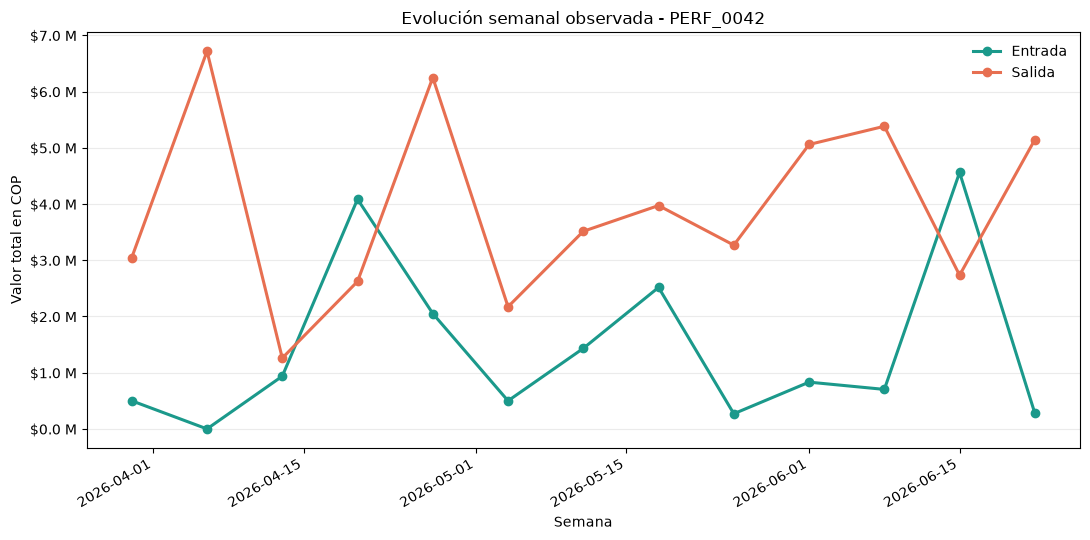

In [13]:
#Graficar evolución semanal
perfiles_regulares = recurrencias.loc[
    recurrencias['estado_patron'].eq('regularidad_observada'),
    'perfil_id',
].value_counts()
perfil_grafica = perfiles_regulares.index[0] if not perfiles_regulares.empty else transacciones['perfil_id'].iloc[0]

historia_grafica = transacciones.loc[transacciones['perfil_id'].eq(perfil_grafica)].copy()
historia_grafica['semana'] = historia_grafica['fecha'] - pd.to_timedelta(
    historia_grafica['fecha'].dt.weekday,
    unit='D',
)
serie_grafica = historia_grafica.pivot_table(
    index='semana',
    columns='direccion',
    values='valor',
    aggfunc='sum',
    fill_value=0,
).sort_index()

figura, eje = plt.subplots(figsize=(11, 5.5))
colores = {'entrada': '#1B998B', 'salida': '#E76F51'}

for direccion in ['entrada', 'salida']:
    if direccion in serie_grafica.columns:
        eje.plot(
            serie_grafica.index,
            serie_grafica[direccion],
            marker='o',
            linewidth=2.2,
            label=direccion.capitalize(),
            color=colores[direccion],
        )

eje.set_title(f'Evolución semanal observada - {perfil_grafica}')
eje.set_xlabel('Semana')
eje.set_ylabel('Valor total en COP')
eje.yaxis.set_major_formatter(FuncFormatter(lambda valor, posicion: f'${valor / 1_000_000:.1f} M'))
eje.legend(frameon=False)
eje.grid(axis='y', alpha=0.25)
figura.autofmt_xdate()
figura.tight_layout()

ruta_graficas.mkdir(parents=True, exist_ok=True)
figura.savefig(ruta_graficas / '03_evolucion_semanal_perfil.png', dpi=180, bbox_inches='tight')
plt.show()

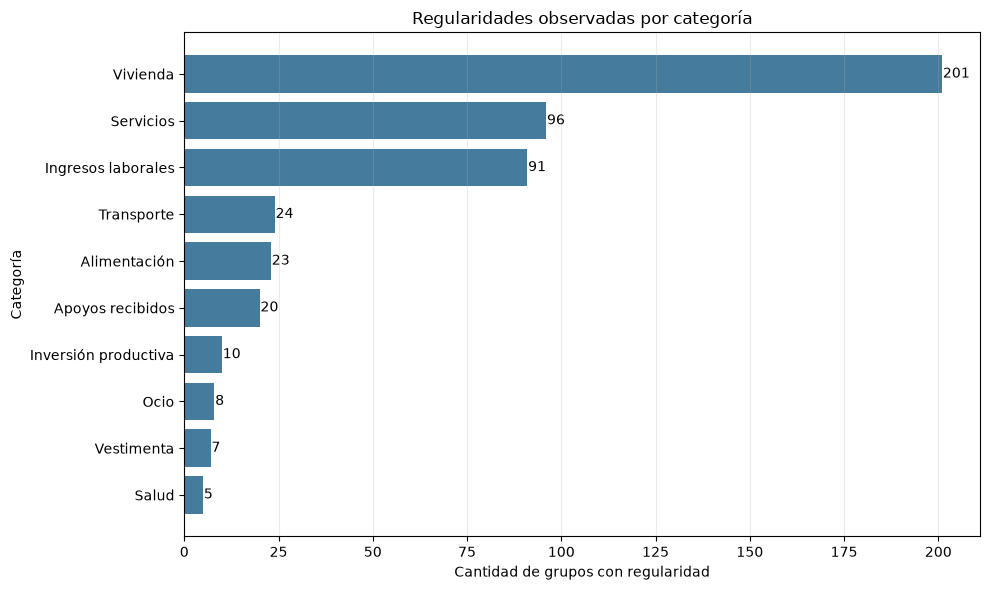

In [14]:
#Graficar regularidades
regularidades_categoria = recurrencias.loc[
    recurrencias['estado_patron'].eq('regularidad_observada')
].groupby('categoria_principal').size().sort_values(ascending=False).head(10).sort_values()

figura, eje = plt.subplots(figsize=(10, 6))
eje.barh(regularidades_categoria.index, regularidades_categoria.values, color='#457B9D')
eje.set_title('Regularidades observadas por categoría')
eje.set_xlabel('Cantidad de grupos con regularidad')
eje.set_ylabel('Categoría')
eje.grid(axis='x', alpha=0.25)

for posicion, valor in enumerate(regularidades_categoria.values):
    eje.text(valor + 0.2, posicion, str(int(valor)), va='center')

figura.tight_layout()
figura.savefig(ruta_graficas / '03_regularidades_por_categoria.png', dpi=180, bbox_inches='tight')
plt.show()

## 9. Exportación

In [15]:
#Guardar resultados
ruta_resultados.mkdir(parents=True, exist_ok=True)

archivos_generados = {
    'recurrencias': ruta_resultados / '03_recurrencias_observadas.csv',
    'tendencias': ruta_resultados / '03_tendencias_observadas.csv',
    'eventos_inusuales': ruta_resultados / '03_eventos_inusuales.csv',
}

recurrencias.to_csv(archivos_generados['recurrencias'], index=False)
tendencias.to_csv(archivos_generados['tendencias'], index=False)
eventos_inusuales.to_csv(archivos_generados['eventos_inusuales'], index=False)

resumen_archivos = pd.DataFrame([
    {'resultado': nombre, 'ruta': str(ruta), 'filas': len(tabla)}
    for nombre, ruta, tabla in [
        ('recurrencias', archivos_generados['recurrencias'], recurrencias),
        ('tendencias', archivos_generados['tendencias'], tendencias),
        ('eventos_inusuales', archivos_generados['eventos_inusuales'], eventos_inusuales),
    ]
])

display(resumen_archivos)

,resultado,ruta,filas
0,recurrencias,../Resultados/03_recurrencias_observadas.csv,8902
1,tendencias,../Resultados/03_tendencias_observadas.csv,396
2,eventos_inusuales,../Resultados/03_eventos_inusuales.csv,646


## 10. Pruebas manuales

In [16]:
#Probar recurrencia mensual
test_recurrencia_mensual = pd.DataFrame([
    {'fecha': '2026-01-05', 'descripcion': 'pago arriendo', 'categoria': 'Vivienda', 'valor': 900000},
    {'fecha': '2026-02-05', 'descripcion': 'pago arriendo', 'categoria': 'Vivienda', 'valor': 900000},
    {'fecha': '2026-03-06', 'descripcion': 'pago arriendo', 'categoria': 'Vivienda', 'valor': 900000},
    {'fecha': '2026-04-05', 'descripcion': 'pago arriendo', 'categoria': 'Vivienda', 'valor': 900000},
])

resultado_recurrencia_mensual = pd.DataFrame([
    {
        'caso': 'recurrencia_mensual_clara',
        **evaluar_fechas(test_recurrencia_mensual['fecha']),
    }
])

display(test_recurrencia_mensual)
display(resultado_recurrencia_mensual)
assert resultado_recurrencia_mensual.loc[0, 'estado_patron'] == 'regularidad_observada'
assert resultado_recurrencia_mensual.loc[0, 'cadencia_observada'] == 'mensual'
assert resultado_recurrencia_mensual.loc[0, 'naturaleza_observada'] == 'fijo'

,fecha,descripcion,categoria,valor
0,2026-01-05,pago arriendo,Vivienda,900000
1,2026-02-05,pago arriendo,Vivienda,900000
2,2026-03-06,pago arriendo,Vivienda,900000
3,2026-04-05,pago arriendo,Vivienda,900000


,caso,fechas_distintas,intervalo_mediano_dias,dispersion_intervalo_dias,cadencia_observada,regularidad_pct,estado_patron,naturaleza_observada,nivel_incertidumbre
0,recurrencia_mensual_clara,4,30.0,1.0,mensual,100.0,regularidad_observada,fijo,baja


In [17]:
#Probar historia irregular
test_historia_irregular = pd.DataFrame([
    {'fecha': '2026-01-02', 'descripcion': 'compra variable', 'categoria': 'Otra / ambigua', 'valor': 35000},
    {'fecha': '2026-01-05', 'descripcion': 'compra variable', 'categoria': 'Otra / ambigua', 'valor': 42000},
    {'fecha': '2026-02-20', 'descripcion': 'compra variable', 'categoria': 'Otra / ambigua', 'valor': 28000},
    {'fecha': '2026-04-01', 'descripcion': 'compra variable', 'categoria': 'Otra / ambigua', 'valor': 51000},
])

resultado_historia_irregular = pd.DataFrame([
    {
        'caso': 'repeticion_sin_periodicidad',
        **evaluar_fechas(test_historia_irregular['fecha']),
    }
])

display(test_historia_irregular)
display(resultado_historia_irregular)
assert resultado_historia_irregular.loc[0, 'estado_patron'] == 'sin_regularidad_suficiente'
assert resultado_historia_irregular.loc[0, 'cadencia_observada'] == 'irregular'
assert resultado_historia_irregular.loc[0, 'naturaleza_observada'] == 'variable'

,fecha,descripcion,categoria,valor
0,2026-01-02,compra variable,Otra / ambigua,35000
1,2026-01-05,compra variable,Otra / ambigua,42000
2,2026-02-20,compra variable,Otra / ambigua,28000
3,2026-04-01,compra variable,Otra / ambigua,51000


,caso,fechas_distintas,intervalo_mediano_dias,dispersion_intervalo_dias,cadencia_observada,regularidad_pct,estado_patron,naturaleza_observada,nivel_incertidumbre
0,repeticion_sin_periodicidad,4,40.0,6.0,irregular,0.0,sin_regularidad_suficiente,variable,media


In [18]:
#Probar historia insuficiente
test_historia_corta = pd.DataFrame([
    {'fecha': '2026-04-15', 'descripcion': 'compra única', 'categoria': 'Ocio', 'valor': 120000},
])

resultado_historia_corta = pd.DataFrame([
    {
        'caso': 'una_sola_transaccion',
        **evaluar_fechas(test_historia_corta['fecha']),
    }
])

display(test_historia_corta)
display(resultado_historia_corta)
assert resultado_historia_corta.loc[0, 'estado_patron'] == 'evidencia_insuficiente'
assert resultado_historia_corta.loc[0, 'cadencia_observada'] == 'no_determinable'
assert resultado_historia_corta.loc[0, 'naturaleza_observada'] == 'no_determinable'

,fecha,descripcion,categoria,valor
0,2026-04-15,compra única,Ocio,120000


,caso,fechas_distintas,intervalo_mediano_dias,dispersion_intervalo_dias,cadencia_observada,regularidad_pct,estado_patron,naturaleza_observada,nivel_incertidumbre
0,una_sola_transaccion,1,NaN,NaN,no_determinable,0.0,evidencia_insuficiente,no_determinable,alta
